In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme()

In [3]:
simexp_path = Path.cwd().parent / "simulation_result"

In [5]:
df = pd.read_csv(simexp_path / "pareto_front_strategy1a.csv")

In [6]:
df.head()

,generation,file,entry,id,reward,energy_consumption_average,packet_loss_average
0,0,pareto_front_001,0,Task 67,157.494,10.305274,0.122226
1,0,pareto_front_001,1,Task 52,157.262,10.191107,0.126307
2,0,pareto_front_001,2,Task 31,157.049,10.420911,0.121611
3,0,pareto_front_001,3,Task 35,157.151,10.465072,0.120266
4,0,pareto_front_001,4,Task 166,157.255,10.148643,0.126749


In [7]:
gens = df["generation"].drop_duplicates()
#print("gens: %s" % gens)
selected_gens = sorted(
    set([gens.iloc[0], gens.iloc[-1]] + list(gens.iloc[::7]))
)
print("selected: %s" % selected_gens)
df_reduced = df[df["generation"].isin(selected_gens)]

selected: [np.int64(0), 7, 14, 21, np.int64(27)]


In [8]:
df_reduced.head()

,generation,file,entry,id,reward,energy_consumption_average,packet_loss_average
0,0,pareto_front_001,0,Task 67,157.494,10.305274,0.122226
1,0,pareto_front_001,1,Task 52,157.262,10.191107,0.126307
2,0,pareto_front_001,2,Task 31,157.049,10.420911,0.121611
3,0,pareto_front_001,3,Task 35,157.151,10.465072,0.120266
4,0,pareto_front_001,4,Task 166,157.255,10.148643,0.126749


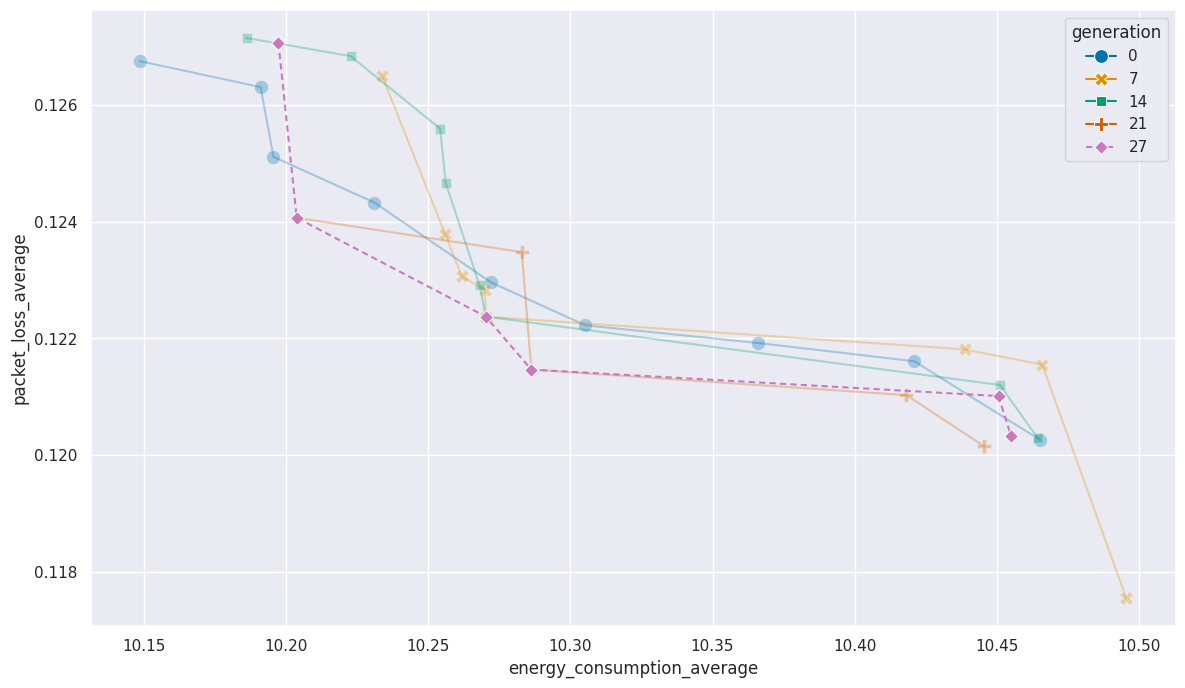

In [9]:
dashes_dict = {gen: () for gen in df_reduced["generation"].unique()}
dashes_dict[27] = (3, 2)  # 3 points line, 2 points space = dashed

plt.figure(figsize=(14, 8))
ax = sns.lineplot(data=df_reduced,
             x="energy_consumption_average", y="packet_loss_average",
             hue="generation", style="generation",
             markers=True,
             markersize=10,
             #dashes=False,
             dashes=dashes_dict,
             legend="full",
             palette="colorblind",
             #alpha=1,
            )
handles, labels = ax.get_legend_handles_labels()
for line, label in zip(ax.lines, labels):
    if label == "27":
        line.set_alpha(1.0)   # fully opaque
        #line.set_linewidth(3)
    else:
        line.set_alpha(0.3)   # others semi-transparent
plt.show()